In [2]:
import sys
sys.path.append("../")
import numpy as np
from utils.noise_generator import ColoredNoiseGenerator_Cholesky

def build_C_from_alpha(alpha, tgrid):
    N = len(tgrid)
    C = np.zeros((N, N), dtype=complex)
    for i in range(N):
        for j in range(N):
            C[i, j] = alpha(tgrid[j] - tgrid[i])
    return C

def rel_fro_error(A, B, eps=1e-15):
    return np.linalg.norm(A - B, 'fro') / (np.linalg.norm(B, 'fro') + eps)

def alpha(t):
    g = 2
    w = 0.5 + 2j
    a = lambda t: g * np.exp(-w * t)
    if t >= 0:
        return a(t)
    else:
        return np.conj(a(-t))

steps = 10
tmax = np.pi
dt = tmax / steps
tgrid = np.linspace(0, tmax, steps + 1)

C = build_C_from_alpha(alpha, tgrid)

noise_generator = ColoredNoiseGenerator_Cholesky(alpha, t_stop=tmax, N_steps=steps)

N_samples = 100000
C_hat = 0

for n in range(N_samples):
    z = noise_generator.sample_process()
    C_hat += np.outer(z, z.conj())

C_hat /= N_samples

print("Relative Frobenius error:", rel_fro_error(C_hat, C))

Relative Frobenius error: 0.0060484344958535415


In [2]:
# bath correlation function in Cai_2020_CPAM
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
CapL = 200
factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)
cl = wl * np.sqrt((0.2 * wc/CapL) * factor)

_coth = 1.0 / np.tanh(0.5 * beta * wl)
_pref = (cl**2) / (2.0 * wl)
def bath_corr(t):
    """
    Bath correlation function alpha(t).
    Supports scalar t or 1D array t (returns same shape).
    """
    # t_arr = np.asarray(t)
    # t1 = np.atleast_1d(t_arr).astype(float)
    # phase = wl[:, None] * t1[None, :]             # shape: (CapL, len(t))
    # out = np.sum(_pref[:, None] * (np.cos(phase) * _coth[:, None] - 1j * np.sin(phase)), axis=0)
    # return out[0] if t_arr.ndim == 0 else out
    res = 0
    for l in range(CapL):
        res += _pref[l] * (_coth[l] * np.cos(wl[l]*t) - 1j * np.sin(wl[l]*t))
    return res

tmax = 5/Delta
steps = 50
dt = tmax / steps
tgrid = np.linspace(0, tmax, steps + 1)


noise_generator = ColoredNoiseGenerator_Cholesky(bath_corr, t_stop=tmax, N_steps=steps)

In [12]:
base = 50
rank = 8
N_steps = np.array([1, 2, 4,]) * base

for steps in N_steps:
    tgrid = np.linspace(0, tmax, steps + 1)
    dt = tmax / steps
    C = np.zeros((steps + 1, steps + 1), dtype=complex)
    for i in range(steps + 1):
        for j in range(steps + 1):
            C[i, j] = bath_corr(tgrid[i] - tgrid[j])
    diag_weight = np.sqrt(dt) * np.ones(steps + 1)
    diag_weight[0] = np.sqrt(0.5 * dt)
    diag_weight[-1] = np.sqrt(0.5 * dt)
    W_half = np.diag(diag_weight)
    W_half_inv = np.diag(1.0 / diag_weight)
    U, S, V = np.linalg.svd(W_half @ C @ W_half)
    V = V @ W_half_inv
    U = W_half_inv @ U
    print(f"Steps: {steps}, first few singular values: {S[:rank]}")
    # print(f"first few vectors: {U[:2*(steps//base), :2*(steps//base)]}")
    # C_approx = U[:, :r] @ np.diag(S[:r]) @ V[:r, :]
    # print(f"Steps: {steps}, Relative Frobenius error of rank-{r} approximation: {rel_fro_error(C_approx, C)}")
    # C_approx = U[:, :rank] @ np.diag(S[:rank]) @ V[:rank, :]
    # print(f"Steps: {steps}, Relative Frobenius error of rank-{rank} approximation: {rel_fro_error(C_approx, C)}")

Steps: 50, first few singular values: [0.56247485 0.51934857 0.45661906 0.38440679 0.31175611 0.24514476
 0.18800731 0.14098959]
Steps: 100, first few singular values: [0.562511   0.51947373 0.45684317 0.38468918 0.31203962 0.24538368
 0.18816534 0.14103919]
Steps: 200, first few singular values: [0.56252009 0.5195052  0.4568994  0.38475982 0.31211032 0.24544306
 0.18820449 0.14105151]


In [4]:
def generate_complex_gaussian():
    n1 = np.random.normal()
    n2 = np.random.normal()
    return (n1 + 1j * n2) / np.sqrt(2)

rank = 10
steps = 100
trajs = 10000
tgrid = np.linspace(0, tmax, steps + 1)
dt = tmax / steps
C = np.zeros((steps + 1, steps + 1), dtype=complex)
for i in range(steps + 1):
    for j in range(steps + 1):
        C[i, j] = bath_corr(tgrid[i] - tgrid[j])
U, S, V = np.linalg.svd(dt * C)
U = U / np.sqrt(dt)
V = V / np.sqrt(dt)
print(f"Steps: {steps}, first few singular values: {S[:rank]}")
U_ = U[:, :rank]
V_ = V[:rank, :]
print(f"error: {np.linalg.norm(U_.conj().T - V_)}")
C_ = U_ @ np.diag(S[:rank]) @ V_
print(f"Relative Frobenius error of rank-{rank} approximation: {np.linalg.norm(C_ - C)/np.linalg.norm(C)}") 

rand_mat = np.zeros((steps+1, steps+1), dtype=complex)
for traj in range(trajs):
    z = np.zeros(steps + 1, dtype=complex)
    for k in range(rank):
        z[:] += generate_complex_gaussian() * np.sqrt(S[k]) * V_[k, :]
    rand_mat += np.outer(z.conj(), z)
rand_mat /= trajs
print(f"Error of generated noise covariance: {np.linalg.norm(rand_mat - C_)/np.linalg.norm(C_)}")

Steps: 100, first few singular values: [0.56280331 0.52053314 0.45884672 0.3874996  0.31540233 0.24900185
 0.19167854 0.14396978 0.09025858 0.0297326 ]
error: 4.627005588073461e-14
Relative Frobenius error of rank-10 approximation: 0.005592023015021963
Error of generated noise covariance: 0.025631918334482702


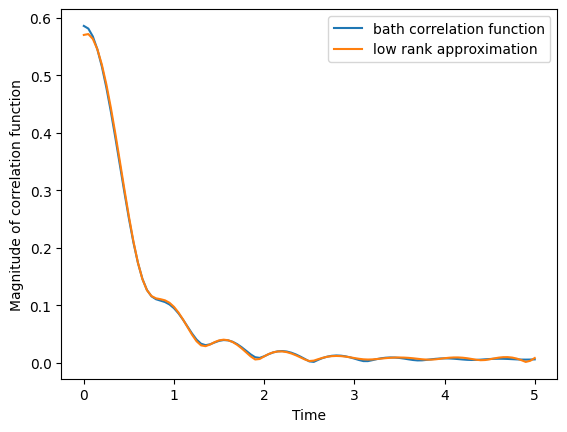

In [5]:
import matplotlib.pyplot as plt

rank = 10
steps = 100
tgrid = np.linspace(0, tmax, steps + 1)
dt = tmax / steps
C = np.zeros((steps + 1, steps + 1), dtype=complex)
for i in range(steps + 1):
    for j in range(steps + 1):
        C[i, j] = bath_corr(tgrid[i] - tgrid[j])
U, S, V = np.linalg.svd(dt * C)
U = U / np.sqrt(dt)
V = V / np.sqrt(dt)

U_ = U[:, :rank]
V_ = V[:rank, :]
C_ = U_ @ np.diag(S[:rank]) @ V_

# bath correlation function in Cai_2020_CPAM
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
CapL = 200
factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)
cl = wl * np.sqrt((0.2 * wc/CapL) * factor)
_coth = 1.0 / np.tanh(0.5 * beta * wl)
_pref = (cl**2) / (2.0 * wl)
def bath_corr_prin_comp(t):
    res = 0
    for l in range(rank):
        res += _pref[l] * (_coth[l] * np.cos(wl[l]*t) - 1j * np.sin(wl[l]*t))
    return res
prin_comp = np.array([bath_corr_prin_comp(t) for t in tgrid])

plt.plot(tgrid, np.abs(C[:,0]), label='bath correlation function')
plt.plot(tgrid, np.abs(C_[:,0]), label='low rank approximation')
# plt.plot(tgrid, np.abs(prin_comp), label='principal components')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Magnitude of correlation function')
plt.show()

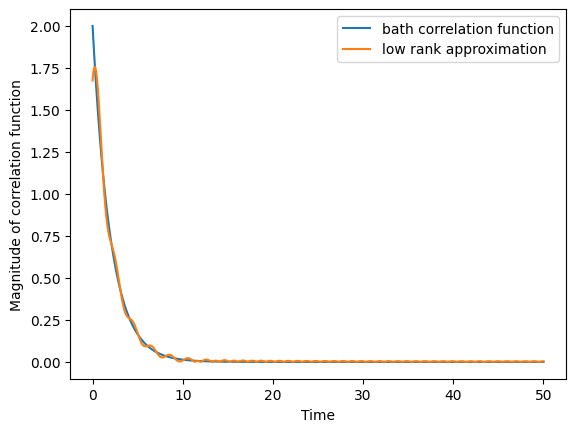

In [7]:
import numpy as np
import matplotlib.pyplot as plt
## Test HOPS bath correlation function
# Spin-Boson model
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
Delta = 1
epsilon = 0
Hs = -0.5 * Delta * sx + 0.5 * epsilon * sz
L = sz

g = 2
w = 0.5 + 2j
def bath_corr(t):
    t1 = np.asarray(t)
    # t1 = np.atleast_1d(t_arr).astype(float)
    return g * np.exp(-w * t1) * (t1 >= 0) + g * np.exp(-np.conj(w) * (-t1)) * (t1 < 0)

rank = 50
tmax = 50 / Delta
steps = 500
dt = tmax / steps
tgrid = np.linspace(0, tmax, steps + 1)
C = np.zeros((steps + 1, steps + 1), dtype=complex)
for i in range(steps + 1):
    for j in range(steps + 1):
        C[i, j] = bath_corr(tgrid[i] - tgrid[j])

U, S, V = np.linalg.svd(dt * C)
U = U / np.sqrt(dt)
V = V / np.sqrt(dt)

U_ = U[:, :rank]
V_ = V[:rank, :]
C_ = U_ @ np.diag(S[:rank]) @ V_

plt.plot(tgrid, np.abs(C[:,0]), label='bath correlation function')
plt.plot(tgrid, np.abs(C_[:,0]), label='low rank approximation')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Magnitude of correlation function')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../")
from utils.noise_generator import ColoredNoiseGenerator_Cholesky

# ==========================================
# Cai_2020_CPAM bath discretization (your code)
# ==========================================
Delta = 1
beta = 5/Delta
wc = 2.5 * Delta
wmax = 4 * wc
CapL = 200

factor = 1 - np.exp(-wmax/wc)
wl = -wc * np.log(1 - np.linspace(1, CapL, CapL)/CapL * factor)   # omega_l
cl = wl * np.sqrt((0.2 * wc/CapL) * factor)

_coth = 1.0 / np.tanh(0.5 * beta * wl)                             # coth(beta omega/2)
_pref = (cl**2) / (2.0 * wl)                                       # pref_l = c_l^2/(2 omega_l)

def bath_corr(t):
    t_arr = np.asarray(t)
    t1 = np.atleast_1d(t_arr).astype(float)
    phase = wl[:, None] * t1[None, :]
    out = np.sum(_pref[:, None] * (np.cos(phase) * _coth[:, None] - 1j * np.sin(phase)), axis=0)
    return out[0] if t_arr.ndim == 0 else out

# ==========================================
# Proper complex Gaussian noise satisfying:
# E z = 0, E zz = 0, E z(t) z(s)^* = alpha(t-s)
# z(t)= sum sqrt(pref_l) [ A_l xi_l e^{-i w_l t} + B_l eta_l e^{+i w_l t} ]
# A_l^2=(coth_l+1)/2, B_l^2=(coth_l-1)/2
# xi,eta iid CN(0,1), independent
# ==========================================
A = np.sqrt((_coth + 1.0) / 2.0)   # (L,)
B = np.sqrt((_coth - 1.0) / 2.0)   # (L,)
sqrt_pref = np.sqrt(_pref)         # (L,)

def sample_cn01(rng, shape):
    # proper complex N(0,1): E[zz]=0, E[|z|^2]=1
    return (rng.standard_normal(shape) + 1j * rng.standard_normal(shape)) / np.sqrt(2.0)

def noise_on_grid(tgrid, xi, eta):
    """
    tgrid: (N,)
    xi, eta: (M,L) CN(0,1)
    returns Z: (M,N)
    """
    # exp matrices: (N,L)
    Eminus = np.exp(-1j * np.outer(tgrid, wl))
    Eplus  = np.exp(+1j * np.outer(tgrid, wl))

    # weights: (L,)
    w1 = sqrt_pref * A
    w2 = sqrt_pref * B

    # (M,L)@(L,N) -> (M,N)
    Z = (xi * w1[None, :]) @ Eminus.T + (eta * w2[None, :]) @ Eplus.T
    return Z

# ==========================================
# Random ODE: X' = mu X + sigma X z(t)
# Euler & reference (via trapezoid in exponent)
# ==========================================
def euler_solver(mu, sigma, x0, T, Z):
    M, Np1 = Z.shape
    N = Np1 - 1
    dt = T / N
    X = np.full(M, x0, dtype=np.complex128)
    for n in range(N):
        X = X + (mu * X + sigma * X * Z[:, n]) * dt
    return X

def reference_solution(mu, sigma, x0, T, Zref):
    M, Np1 = Zref.shape
    Nref = Np1 - 1
    dt = T / Nref
    I = dt * (0.5 * Zref[:, 0] + Zref[:, 1:-1].sum(axis=1) + 0.5 * Zref[:, -1])
    return x0 * np.exp(mu * T + sigma * I)

def fit_order(dts, errs):
    return np.polyfit(np.log(dts), np.log(errs), 1)[0]

def main():
    # ---- experiment params ----
    rng = np.random.default_rng(2026)
    M = 50000          # increase if weak tail noisy
    T = 1.0

    mu = 1.0
    sigma = 0.5
    x0 = 1.0

    # ---- sample xi, eta once (same noise paths for all dt) ----
    xi  = sample_cn01(rng, (M, CapL))
    eta = sample_cn01(rng, (M, CapL))

    # ---- (A) quick Monte-Carlo check of the 3 conditions ----
    # pick a few times
    tcheck = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
    # Zc = noise_on_grid(tcheck, xi, eta)  # (M, len(tcheck))
    # generate noise trajectories for strong error
    Zc = np.empty((M, 5), dtype=np.complex128)
    noise_gen = ColoredNoiseGenerator_Cholesky(bath_corr, 1.0, 4)
    for traj in range(M):
        z = np.asarray(noise_gen.sample_process(), dtype=np.complex128)
        Zc[traj, :] = z[:]

    # E[z_t] ~ 0
    Ez = Zc.mean(axis=0)

    # check E[z(t_i) z(t_j)] ~ 0 and E[z(t_i) z(t_j)^*] ~ alpha(t_i - t_j)
    # compute empirical covariances
    Emp_zz   = (Zc[:, :, None] * Zc[:, None, :]).mean(axis=0)              # (k,k)
    Emp_zzc  = (Zc[:, :, None] * np.conj(Zc[:, None, :])).mean(axis=0)     # (k,k)

    # theory alpha(t_i - t_j)
    Dt = tcheck[:, None] - tcheck[None, :]
    Th = np.vectorize(bath_corr)(-Dt)

    print("Check E[z(t)] (should be ~0):")
    print(Ez)

    print("\nMax |E[z(t_i) z(t_j)]| (should be small):", np.max(np.abs(Emp_zz)))
    print("Max |E[z(t_i) z(t_j)^*] - alpha(t_i-t_j)|:", np.max(np.abs(Emp_zzc - Th)))

    # ---- (B) convergence test ----
    # reference on fine grid
    Nref = 2**10
    t_ref = np.linspace(0.0, T, Nref + 1)

    # Zref = noise_on_grid(t_ref, xi, eta)
    Zref = np.empty((M, Nref+1), dtype=np.complex128)
    noise_gen = ColoredNoiseGenerator_Cholesky(bath_corr, T, Nref)
    for traj in range(M):
        z = np.asarray(noise_gen.sample_process(), dtype=np.complex128)
        Zref[traj, :] = z[:]

    Xref = reference_solution(mu, sigma, x0, T, Zref)
    # Xref = euler_solver(mu, sigma, x0, T, Zref)

    ks = np.array([4, 5, 6, 7, 8], dtype=int)  # N=16..1024
    Ns = 2**ks
    dts = T / Ns

    strong_err = []
    weak_err = []

    for N in Ns:
        t = np.linspace(0.0, T, N + 1)

        # Z = noise_on_grid(t, xi, eta)
        Z = np.empty((M, N+1), dtype=np.complex128)
        # noise_gen = ColoredNoiseGenerator_Cholesky(bath_corr, T, N)
        # for traj in range(M):
        #     z = np.asarray(noise_gen.sample_process(), dtype=np.complex128)
        #     Z[traj, :] = z[:]
        for traj in range(M):
            Z[traj, :] = Zref[traj, ::(Nref//N)]  # subsample from fine grid

        Xnum = euler_solver(mu, sigma, x0, T, Z)

        se = np.mean(np.abs(Xnum - Xref))                 # strong
        we = np.abs(np.mean(Xnum) - np.mean(Xref))        # weak

        strong_err.append(se)
        weak_err.append(we)
        print(f"N={N:4d}, dt={T/N:.3e}, strong={se:.3e}, weak={we:.3e}")

    strong_err = np.array(strong_err)
    weak_err = np.array(weak_err)

    pS = fit_order(dts, strong_err)
    pW = fit_order(dts, weak_err)
    print(f"\nObserved orders: strong ≈ {pS:.3f}, weak ≈ {pW:.3f}")

    # plot both on one figure
    plt.figure(figsize=(8, 6))
    plt.loglog(dts, strong_err, "o-", label=f"Strong (≈{pS:.2f})")
    plt.loglog(dts, weak_err,   "s-", label=f"Weak   (≈{pW:.2f})")

    # reference slope 1
    C = strong_err[0] / dts[0]
    plt.loglog(dts, C * dts, "--", label="Ref slope 1")

    plt.gca().invert_xaxis()
    plt.xlabel("dt")
    plt.ylabel("Error")
    plt.title("Euler convergence with Cai bath proper complex noise")
    plt.grid(True, which="both", linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
base = 50
rank = 4
N_steps = np.array([1, 2, 4, 8]) * base

for steps in N_steps:
    tgrid = np.linspace(0, tmax, steps + 1)
    dt = tmax / steps
    C = np.zeros((steps + 1, steps + 1), dtype=complex)
    for i in range(steps + 1):
        for j in range(steps + 1):
            C[i, j] = dt * bath_corr(tgrid[i] - tgrid[j])
    U, S, V = np.linalg.svd(C)
    U = U / np.sqrt(dt)
    V = V / np.sqrt(dt)

    ds = steps // base
    U_interp = U[::ds, :rank]
    V_interp = V[:rank, ::ds]
    print(f"Steps: {steps}, first few singular values: {S[:rank]}")
    print(f"Steps: {steps}, first few vectors (U): {U_interp[:rank, 0]}")
    print(f"Steps: {steps}, first few vectors (V): {V_interp[0, :rank]}")